# PCA + Topology Forecasting

This notebook tests the revised paper framing:

1. market-implied probability baseline
2. family-level PCA enhancement
3. family-level PCA plus topology enhancement

This is not a PCA-vs-topology experiment. The question is whether scalar topological summaries add incremental forecasting signal beyond the successful PCA-enhanced benchmark.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == 'notebooks':
    PROJECT = PROJECT.parent
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from pca_plus_topology_forecasting import model_summary, run_all

OUT = PROJECT / 'data' / 'processed'
OUT.mkdir(parents=True, exist_ok=True)
RUN_FULL = False

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Run Or Reuse Outputs

By default, this notebook reuses the saved outputs. Set `RUN_FULL = True` in the cell above to regenerate the benchmark.

In [2]:
required = [
    OUT / 'pca_plus_topology_results.csv',
    OUT / 'pca_plus_topology_predictions.parquet',
    OUT / 'pca_plus_topology_calibration_by_decile.csv',
    OUT / 'pca_plus_topology_summary.md',
]

if RUN_FULL or not all(path.exists() for path in required):
    predictions, results, calibration, summary_text = run_all(
        OUT / 'candidate_universe_markets.parquet',
        OUT / 'prices_long.parquet',
        OUT / 'universe_b_macro_crypto_panel.parquet',
        OUT / 'tda_features.parquet',
        OUT,
    )
else:
    results = pd.read_csv(OUT / 'pca_plus_topology_results.csv')
    predictions = pd.read_parquet(OUT / 'pca_plus_topology_predictions.parquet')
    calibration = pd.read_csv(OUT / 'pca_plus_topology_calibration_by_decile.csv')
    summary_text = (OUT / 'pca_plus_topology_summary.md').read_text()

print(summary_text)

PCA + TOPOLOGY FORECASTING SUMMARY

Research framing:
- This is not PCA vs topology.
- The benchmark is market-implied probability, then PCA enhancement, then PCA + topology enhancement.

Dataset:
- markets: 171
- supervised rows: 532,979
- YES rate by unique market: 0.111

Prior benchmarks:
- market probability: Brier 0.0489, log loss 0.1673
- family-level PCA: Brier 0.0445, log loss 0.1625
- scalar TDA alone: Brier 0.0497, log loss 0.1930

This run:
- market probability: market_probability Brier 0.0489, log loss 0.1673
- family PCA: family_pca_fixed_2_standard Brier 0.0445, log loss 0.1625
- scalar TDA: scalar_tda_24h_standard Brier 0.0497, log loss 0.1930
- PCA + scalar TDA: pca_plus_scalar_tda_24h_standard Brier 0.0445, log loss 0.1624

Incremental topology test:
- PCA + topology beats family PCA on both Brier and log loss: yes
- PCA + topology Brier delta vs prior family PCA: -0.0000
- PCA + topology log-loss delta vs prior family PCA: -0.0000

Interpretation:
- Scalar topological

## Overall Results

In [3]:
summary = model_summary(results)
display(summary[[
    'representation', 'model', 'class_weight', 'window_hours', 'folds', 'n_obs',
    'brier', 'log_loss', 'avg_pred', 'avg_actual'
]].sort_values(['brier', 'log_loss']))

,representation,model,class_weight,window_hours,folds,n_obs,brier,log_loss,avg_pred,avg_actual
6,pca_plus_scalar_tda,pca_plus_scalar_tda_24h_standard,standard,24,17,282976,0.044490,0.162435,0.093353,0.08942
1,family_pca,family_pca_fixed_2_standard,standard,0,17,282976,0.044509,0.162468,0.093003,0.08942
8,pca_plus_scalar_tda,pca_plus_scalar_tda_72h_standard,standard,72,17,282976,0.044549,0.162562,0.093996,0.08942
4,pca_plus_scalar_tda,pca_plus_scalar_tda_168h_standard,standard,168,17,282976,0.044610,0.162786,0.094785,0.08942
2,market_probability,market_probability,none,0,17,282976,0.048879,0.167262,0.115554,0.08942
12,scalar_tda,scalar_tda_24h_standard,standard,24,17,282976,0.049736,0.192998,0.058253,0.08942
14,scalar_tda,scalar_tda_72h_standard,standard,72,17,282976,0.050198,0.193704,0.070370,0.08942
10,scalar_tda,scalar_tda_168h_standard,standard,168,17,282976,0.050610,0.194407,0.082384,0.08942
11,scalar_tda,scalar_tda_24h_balanced,balanced,24,17,282976,0.063616,0.231012,0.174598,0.08942
13,scalar_tda,scalar_tda_72h_balanced,balanced,72,17,282976,0.079805,0.277368,0.203833,0.08942


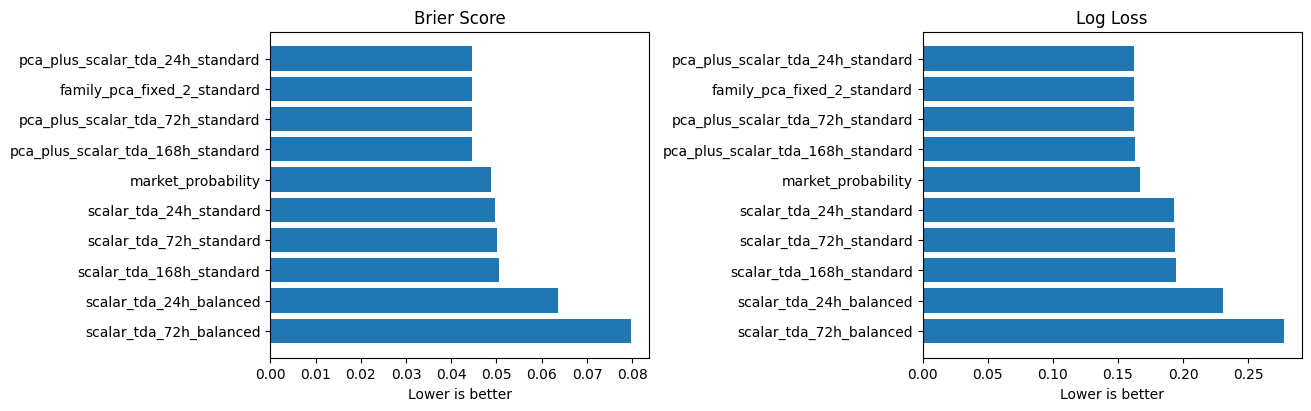

In [4]:
overall = summary.sort_values(['brier', 'log_loss']).copy()
plot_df = overall.head(10).copy()
plot_df['label'] = plot_df['model']

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].barh(plot_df['label'], plot_df['brier'])
axes[0].invert_yaxis()
axes[0].set_title('Brier Score')
axes[0].set_xlabel('Lower is better')

axes[1].barh(plot_df['label'], plot_df['log_loss'])
axes[1].invert_yaxis()
axes[1].set_title('Log Loss')
axes[1].set_xlabel('Lower is better')
plt.show()

## Incremental Test

In [5]:
family = summary[summary['representation'].eq('family_pca')].sort_values(['brier', 'log_loss']).iloc[0]
combo = summary[summary['representation'].eq('pca_plus_scalar_tda')].sort_values(['brier', 'log_loss']).iloc[0]

incremental = pd.DataFrame([
    {
        'comparison': 'PCA + scalar TDA minus family PCA',
        'brier_delta': combo['brier'] - family['brier'],
        'log_loss_delta': combo['log_loss'] - family['log_loss'],
        'best_combo_model': combo['model'],
    }
])
display(incremental)

,comparison,brier_delta,log_loss_delta,best_combo_model
0,PCA + scalar TDA minus family PCA,-0.000018,-0.000033,pca_plus_scalar_tda_24h_standard


## Calibration Snapshot

,fold,representation,model,class_weight,prob_decile,n_obs,avg_pred,avg_actual
10,1,family_pca,family_pca_fixed_2_standard,standard,0,11531,0.019985,0.019860
11,1,family_pca,family_pca_fixed_2_standard,standard,1,779,0.143210,0.012837
12,1,family_pca,family_pca_fixed_2_standard,standard,2,480,0.243178,0.075000
13,1,family_pca,family_pca_fixed_2_standard,standard,3,286,0.350686,0.367133
14,1,family_pca,family_pca_fixed_2_standard,standard,4,295,0.444504,0.311864
15,1,family_pca,family_pca_fixed_2_standard,standard,5,344,0.549946,0.607558
16,1,family_pca,family_pca_fixed_2_standard,standard,6,304,0.642307,0.809211
17,1,family_pca,family_pca_fixed_2_standard,standard,7,208,0.752070,0.634615
18,1,family_pca,family_pca_fixed_2_standard,standard,8,542,0.843238,0.322878
19,1,family_pca,family_pca_fixed_2_standard,standard,9,81,0.914098,0.629630


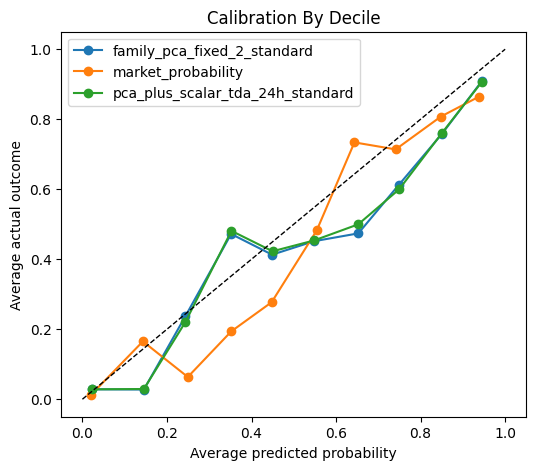

In [6]:
best_models = [
    'market_probability',
    family['model'],
    combo['model'],
]
cal = calibration[calibration['model'].isin(best_models)].copy()
display(cal.head(20))

fig, ax = plt.subplots(figsize=(6, 5))
for model, group in cal.groupby('model'):
    by_decile = group.groupby('prob_decile', as_index=False).agg(avg_pred=('avg_pred', 'mean'), avg_actual=('avg_actual', 'mean'))
    ax.plot(by_decile['avg_pred'], by_decile['avg_actual'], marker='o', label=model)
ax.plot([0, 1], [0, 1], color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Average predicted probability')
ax.set_ylabel('Average actual outcome')
ax.set_title('Calibration By Decile')
ax.legend()
plt.show()